# 02 — Monte Carlo engine & variance reduction

Risk-neutral pricing by simulation: $V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\,\text{payoff}(S)\,]$.

Under GBM the terminal spot has an exact log-space solution — **zero discretization error**:

$$S_T = S_0 \exp\!\Big(\big(r - q - \tfrac{1}{2}\sigma^2\big)T + \sigma\sqrt{T}\,Z\Big), \qquad Z \sim \mathcal{N}(0,1).$$

The engine also implements Euler-Maruyama (strong $O(\sqrt{\Delta t})$) and Milstein
(strong $O(\Delta t)$) for models where no exact scheme exists, plus four variance-reduction
techniques. The estimator's standard error decays as $\text{SE} = \hat\sigma_{\text{payoff}}/\sqrt{N}$
— the point of variance reduction is shrinking the constant, not the rate.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "exotic_option_pricer").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

from exotic_option_pricer.engines import MonteCarloEngine
from exotic_option_pricer.models import BlackScholesModel

S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
bs_price = float(BlackScholesModel(sigma=sigma).price(S0, K, T, r, 'call'))
print(f"Black-Scholes reference: {bs_price:.6f}")

Black-Scholes reference: 10.450584


## Simulated paths

252 daily steps, mean path and 95% distribution band overlaid.

paths shape: (2000, 253)  (n_paths, n_steps + 1)


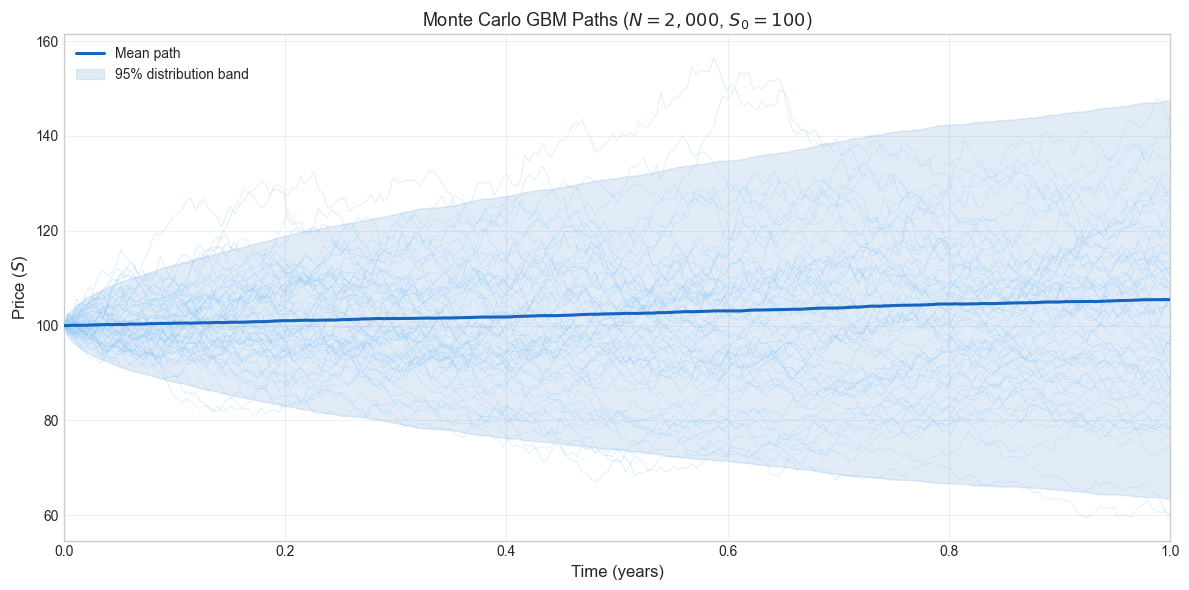

In [2]:
from exotic_option_pricer.utils.visualization import plot_mc_paths

viz_engine = MonteCarloEngine(n_paths=2_000, n_steps=252, seed=7)
paths = viz_engine.simulate_gbm(S0, T, r, sigma)
print(f"paths shape: {paths.shape}  (n_paths, n_steps + 1)")
fig, ax = plot_mc_paths(paths, T, n_show=60)

## Convergence: $O(N^{-1/2})$, measured

Same seed across path counts (the first $N$ paths of a larger run are identical to an
$N$-path run — Glasserman 2003, §2.3), absolute error measured against the analytical
Black-Scholes price.

fitted log-log slope of SE vs N: -0.494   (theory: -0.5)


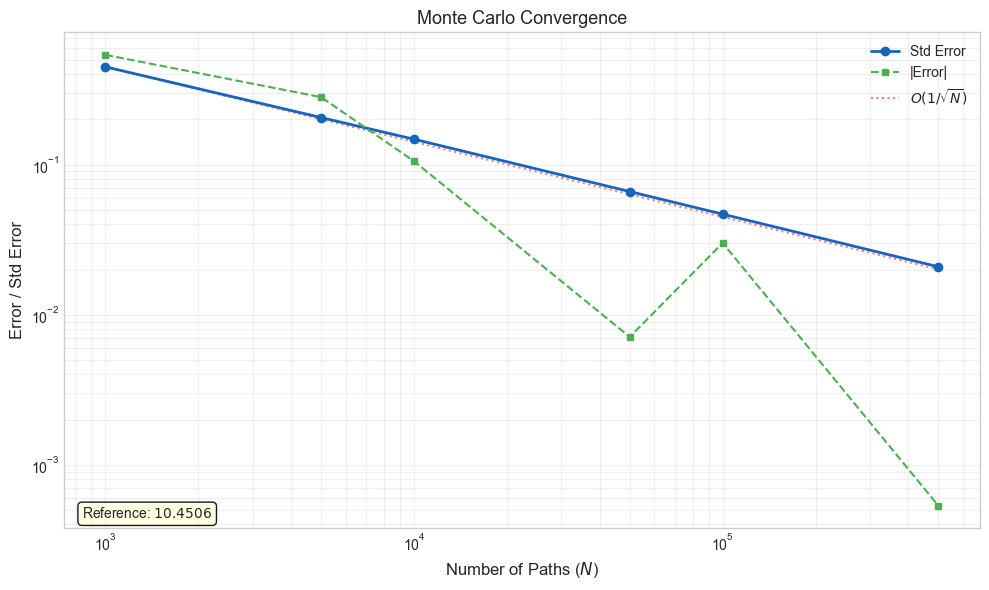

In [3]:
from exotic_option_pricer.utils.visualization import plot_mc_convergence

engine = MonteCarloEngine(n_paths=500_000, seed=42)
conv = engine.convergence_analysis(S0, K, T, r, sigma, reference_price=bs_price)

fig, ax = plot_mc_convergence(
    conv['path_counts'], conv['std_errors'], conv['errors'], conv['reference_price']
)

slope = np.polyfit(np.log(conv['path_counts']), np.log(conv['std_errors']), 1)[0]
print(f"fitted log-log slope of SE vs N: {slope:.3f}   (theory: -0.5)")
assert abs(slope + 0.5) < 0.05

## Variance reduction: four techniques, one benchmark

- **Antithetic variates** — simulate pairs $(Z, -Z)$ and average per pair; the negative
  correlation between the two legs cancels noise.
- **Control variate** — use $e^{-rT}S_T$ (known expectation $S_0 e^{-qT}$) as control with the
  optimal coefficient $\beta^* = \mathrm{Cov}(Y, X)/\mathrm{Var}(X)$; for an ATM call
  $\rho(Y, X) \approx 0.9$, so most of the variance disappears.
- **Combined** — antithetic + control attack different noise components and stack.
- **Quasi-Monte Carlo** — scrambled Sobol points instead of pseudo-random draws; error decays
  close to $O(N^{-1})$. Shown separately below because its reported SE is not a valid iid
  confidence interval.

                method      price  std error  SE ratio
                 plain    10.4500    0.02086     1.000
            antithetic    10.4492    0.01041     0.499
               control    10.4467    0.00792     0.380
  antithetic + control    10.4498    0.00276     0.132


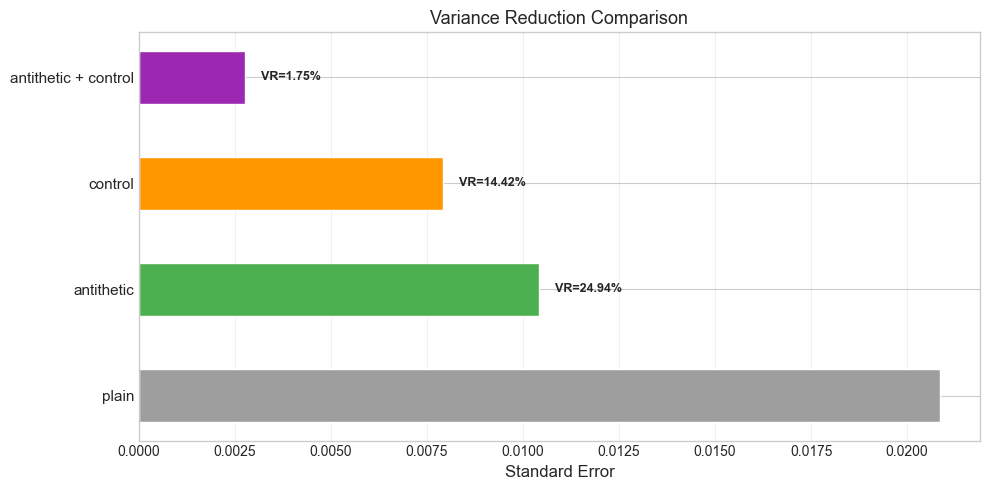

In [4]:
from exotic_option_pricer.utils.visualization import plot_variance_reduction_comparison

engine = MonteCarloEngine(n_paths=500_000, seed=42)
results = {
    'plain': engine.price_european(S0, K, T, r, sigma, 'call'),
    'antithetic': engine.price_european(S0, K, T, r, sigma, 'call', antithetic=True),
    'control': engine.price_european(S0, K, T, r, sigma, 'call', control_variate=True),
    'antithetic + control': engine.price_european(
        S0, K, T, r, sigma, 'call', antithetic=True, control_variate=True
    ),
}

se_plain = results['plain'].std_error
print(f"{'method':>22} {'price':>10} {'std error':>10} {'SE ratio':>9}")
for name, res in results.items():
    print(f"{name:>22} {res.price:>10.4f} {res.std_error:>10.5f} {res.std_error / se_plain:>9.3f}")
    assert abs(res.price - bs_price) < 4 * max(res.std_error, 1e-4)

fig, ax = plot_variance_reduction_comparison(results)
assert results['antithetic + control'].std_error / se_plain < 0.3

## Quasi-Monte Carlo: scrambled Sobol

Same estimator, deterministic low-discrepancy points. The fair comparison is **absolute error
vs the analytical price at equal $N$** — the QMC "standard error" column would be meaningless
because the points are not independent.

In [5]:
qmc_engine = MonteCarloEngine(n_paths=2**16, seed=42)

paths_mc = qmc_engine.simulate_gbm(S0, T, r, sigma, n_steps=1)
paths_qmc = qmc_engine.simulate_gbm(S0, T, r, sigma, n_steps=1, quasi=True)

payoff = lambda p: np.maximum(p[:, -1] - K, 0.0)
res_mc = qmc_engine.price(payoff, paths_mc, r, T)
res_qmc = qmc_engine.price(payoff, paths_qmc, r, T)

print(f"N = 2^16 = {2**16}")
print(f"pseudo-random |error| = {abs(res_mc.price - bs_price):.5f}")
print(f"scrambled Sobol |error| = {abs(res_qmc.price - bs_price):.5f}")
assert abs(res_qmc.price - bs_price) < abs(res_mc.price - bs_price)

N = 2^16 = 65536
pseudo-random |error| = 0.00558
scrambled Sobol |error| = 0.00006


## Importance sampling: deep OTM

For a deep out-of-the-money option almost every plain-MC path pays zero — wasted samples.
The engine shifts the drift so paths land in the money and reweights each one by the
likelihood ratio (Glasserman §4.6), which is unbiased by construction.

In [6]:
K_otm, T_otm = 150.0, 0.25
bs_otm = float(BlackScholesModel(sigma=sigma).price(S0, K_otm, T_otm, r, 'call'))

engine = MonteCarloEngine(n_paths=500_000, seed=42)
res_plain = engine.price_european(S0, K_otm, T_otm, r, sigma, 'call')
res_is = engine.price_european(S0, K_otm, T_otm, r, sigma, 'call', importance_sampling=True)

print(f"BS reference: {bs_otm:.6f}")
print(f"plain: {res_plain.price:.6f}  (SE {res_plain.std_error:.2e})")
print(f"importance sampling: {res_is.price:.6f}  (SE {res_is.std_error:.2e})")
print(f"SE ratio: {res_is.std_error / res_plain.std_error:.3f}")
assert abs(res_is.price - bs_otm) < 4 * res_is.std_error
assert res_is.std_error < res_plain.std_error

BS reference: 0.000118
plain: 0.000244  (SE 7.01e-05)
importance sampling: 0.000118  (SE 2.47e-07)
SE ratio: 0.004


---
**Next:** [03 — Exotic options](03_exotic_options.ipynb) — these paths and variance-reduction
tools plug directly into path-dependent payoffs via the `ExoticOption` interface.